In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

R_X, R_Y = 1.0, 0.6
RAD = 0.5

def t_direct(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    return np.hypot(a[..., 0] - b[..., 0], a[..., 1]- b[..., 1])

def t_express(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    ra = np.hypot(a[..., 0], a[..., 1])
    rb = np.hypot(b[..., 0], b[..., 1])
    return np.abs(ra -RAD)+np.abs(rb-RAD)

def t_time(a, b):
    return np.minimum(t_direct(a,b), t_express(a, b))

In [5]:
PAIRS = [
    (0.45, 0.05, 0.05, 0.45),
    (0.04, 0.13, 0.18, 0.32),
    (0.56, 0.49, 0.16, 0.50),
    (0.20, 0.30, 0.95, 0.40),
    (0.54, 0.30, 0.40, 0.59),
    (0.00, 0.00, 0.60, 0.45),
]

print(f"{'t_D':>13}{'t_E':>10}{'t':>10}   маршрут")
for i, (a1, a2, b1, b2) in enumerate(PAIRS, 1):
    a = np.array([a1, a2])
    b = np.array([b1, b2])
    td = float(t_direct(a, b))
    te = float(t_express(a, b))
    route = 'прямой' if td < te else ('трасса' if te<td else 'равно')
    print(f'{i:<3}{td:>10.4f}{te:>10.4f}{min(td, te):>10.4f}  {route}')

          t_D       t_E         t   маршрут
1      0.5657    0.0945    0.0945  трасса
2      0.2360    0.4968    0.2360  прямой
3      0.4001    0.2691    0.2691  трасса
4      0.7566    0.6702    0.6702  трасса
5      0.3220    0.3305    0.3220  прямой
6      0.7500    0.7500    0.7500  равно


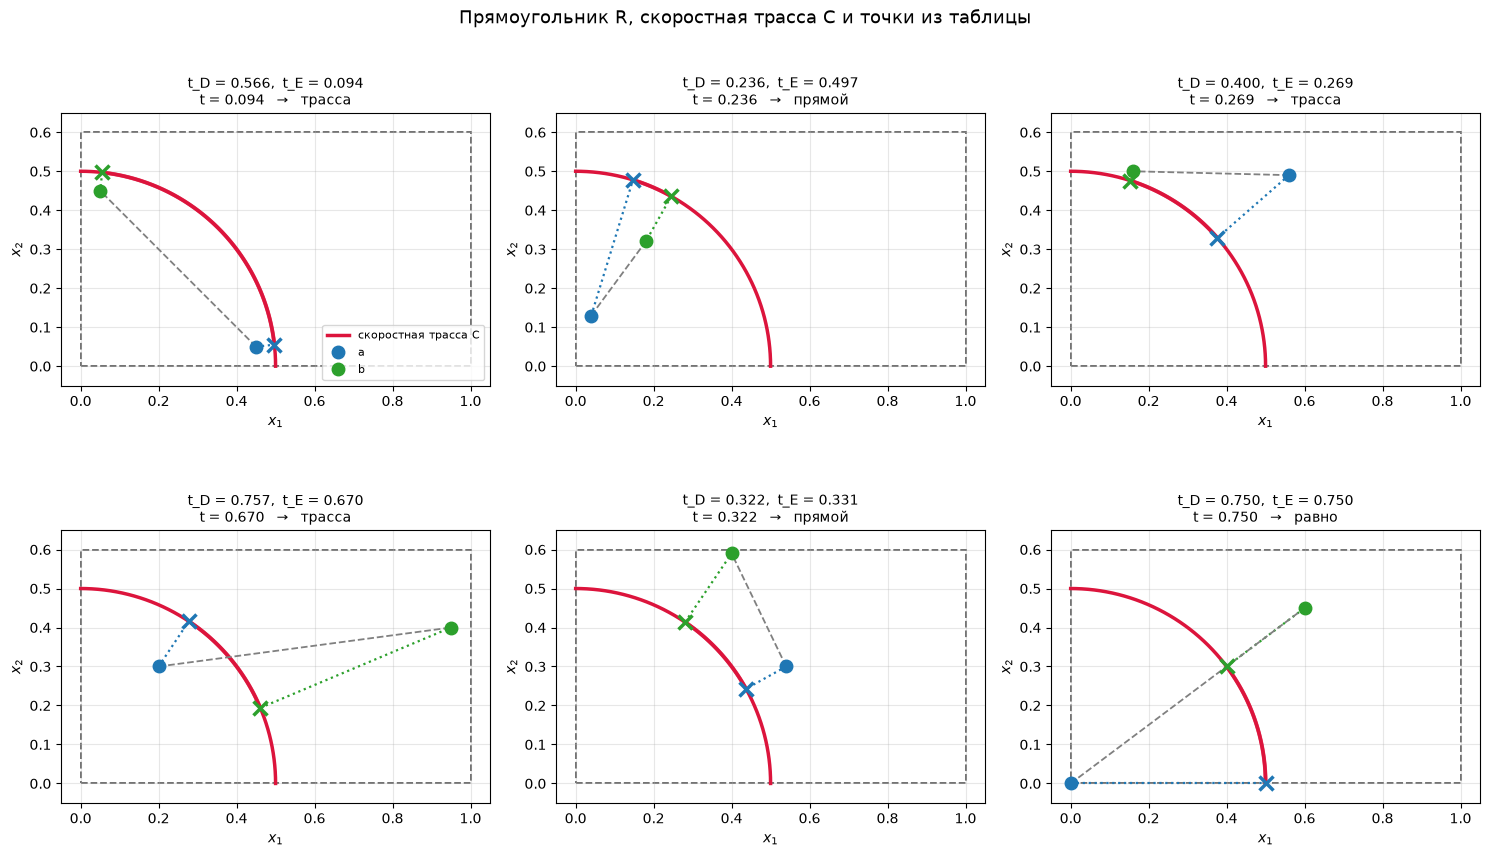

In [7]:
def draw_setup(ax):
    ax.add_patch(Rectangle((0, 0), R_X, R_Y,
                            fill=False, ls="--", ec="0.4", lw=1.3))
    th = np.linspace(0, np.pi / 2, 300)
    x, y = RAD * np.cos(th), RAD * np.sin(th)
    inside = (x >= 0) & (y >= 0) & (y <= R_Y)
    ax.plot(x[inside], y[inside], color="crimson", lw=2.5,
            label="скоростная трасса C")
    ax.set_xlim(-0.05, R_X + 0.05)
    ax.set_ylim(-0.05, R_Y + 0.05)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (a1, a2, b1, b2) in zip(axes.ravel(), PAIRS):
    a = np.array([a1, a2])
    b = np.array([b1, b2])

    def proj(p):
        n = np.hypot(p[0], p[1])
        return np.array([RAD, 0.0]) if n == 0 else RAD * p / n

    at, bt = proj(a), proj(b)
    td, te = float(t_direct(a, b)), float(t_express(a, b))
    best = "трасса" if te < td else ("прямой" if td < te else "равно")

    draw_setup(ax)

    ax.plot(*zip(a, at), color="tab:blue", ls=":",  lw=1.6)
    ax.plot(*zip(bt, b), color="tab:green", ls=":", lw=1.6)

    th_a = np.arctan2(at[1], at[0])
    th_b = np.arctan2(bt[1], bt[0])
    th = np.linspace(min(th_a, th_b), max(th_a, th_b), 80)
    ax.plot(RAD * np.cos(th), RAD * np.sin(th),
            color="crimson", lw=2.8, alpha=0.8)

    ax.plot(*zip(a, b), color="0.5", ls="--", lw=1.3)

    ax.plot(*a, "o", color="tab:blue",  ms=9, label="a")
    ax.plot(*b, "o", color="tab:green", ms=9, label="b")
    ax.plot(*at, "x", color="tab:blue",  ms=10, mew=2.5)
    ax.plot(*bt, "x", color="tab:green", ms=10, mew=2.5)

    ax.set_title(
        f"t_D = {td:.3f},  t_E = {te:.3f}\n"
        f"t = {min(td, te):.3f}   →   {best}",
        fontsize=10
    )

axes[0, 0].legend(loc="lower right", fontsize=8)
plt.suptitle("Прямоугольник R, скоростная трасса C и точки из таблицы", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
np.random.seed(0)
N=1000000
a = np.column_stack([np.random.uniform(0, R_X, N), np.random.uniform(0, R_Y, N)])
b = np.column_stack([np.random.uniform(0, R_X, N), np.random.uniform(0, R_Y, N)])

t = t_time(a, b)
print(f"Среднее t ≈ {t.mean():.4f} ± {t.std()/np.sqrt(N):.4f}")
print(f"Доля пар, где трасса быстрее: {(t_express(a,b) < t_direct(a,b)).mean():.3f}")

Среднее t ≈ 0.3506 ± 0.0002
Доля пар, где трасса быстрее: 0.612
